In [4]:
# D={((1,2),−1),((1.5,0.5),−1),((1.5,3.5),1),((3.5,1),1),((3.5,3),1)}.

import math
import numpy as np

theta_1 = 20/17
theta_2 = 16/17
b = -69/17
theta = np.array([theta_1, theta_2])
theta_abs = math.sqrt(theta_1**2 + theta_2**2)

distance = 1 / theta_abs
print("Distance from hyperplane to closest point:", round(distance, 3))

x_y = []
x_y.append((np.array([1, 2]), -1))
x_y.append((np.array([1.5, 0.5]), -1))
x_y.append((np.array([1.5, 3.5]), 1))
x_y.append((np.array([3.5, 1]), 1))
x_y.append((np.array([3.5, 3]), 1))

is_support_vector = lambda x_y: round(abs(np.dot(theta, x_y[0]) + b), 3) == 1.000

for i in range(len(x_y)):
    print(f"Value for point {i+1}:", round(np.dot(theta, x_y[i][0]) + b, 3))
    print(f"Is point {i+1} a support vector?:", is_support_vector(x_y[i]))

Distance from hyperplane to closest point: 0.664
Value for point 1: -1.0
Is point 1 a support vector?: True
Value for point 2: -1.824
Is point 2 a support vector?: False
Value for point 3: 1.0
Is point 3 a support vector?: True
Value for point 4: 1.0
Is point 4 a support vector?: True
Value for point 5: 2.882
Is point 5 a support vector?: False


In [5]:
# D={((1,3),−1),((4,3),1),((5,3.5),−1),((7,2.5),−1)}

import math

def hinge_loss(D, f):
    """
    Calculate the hinge loss function for data D and function f
    """
    total = 0.0
    for x, y in D:
        total += max(0.0, 1.0 - y * f(x))
    return total

data = [((1,3),-1),((4,3),1),((5,3.5),-1),((7,2.5),-1)]
def fct(x):
    return math.cos((x[0] + x[1] - 3)*math.pi)

hinge_loss_value = hinge_loss(data, fct)

print("Hinge loss:", round(hinge_loss_value, 3))

Hinge loss: 2.0


In [6]:
# D={((2,7),−1),((7.5,0.5),−1),((3,3.3),−1),((2.5,7.5),1),((4,3.8),1),((5,2),1)}
# Use scikit-learn to determine the optimal soft-margin SVM for the data D.
import numpy as np
from sklearn import svm

D = [((2,7),-1),((7.5,0.5),-1),((3,3.3),-1),((2.5,7.5),1),((4,3.8),1),((5,2),1)]
X = np.array([x for x, y in D])
y = np.array([y for x, y in D])
model = svm.SVC(kernel='linear', C=1.0)
model.fit(X, y)
print("Optimal soft-margin SVM coefficients:", [[round(theta1, 3), round(theta2, 3)] for theta1, theta2 in model.coef_])
print("Optimal soft-margin SVM intercept:", [round(intercept, 3) for intercept in model.intercept_])

Optimal soft-margin SVM coefficients: [[np.float64(0.32), np.float64(0.515)]]
Optimal soft-margin SVM intercept: [np.float64(-3.659)]


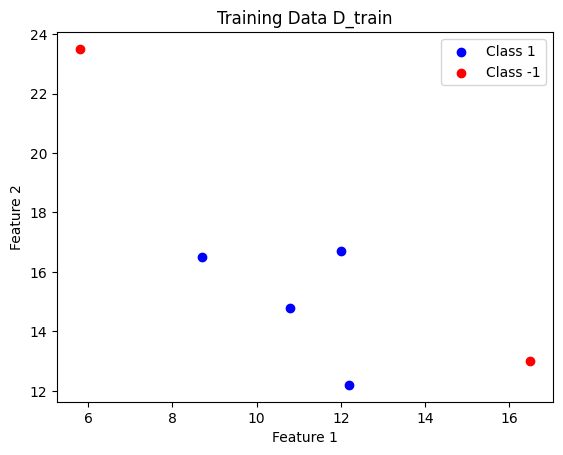

In [7]:
# D_train={((8.7,16.5),1),((10.8,14.8),1),((12,16.7),1),((12.2,12.2),1),((16.5,13),−1),((5.8,23.5),−1)}
# D_test={((13,12.5),1),((6.2,21.3),−1),((6,25.8),1),((8.5,27.7),−1)}

# Plot D_train
import numpy as np
import matplotlib.pyplot as plt

D_train = [((8.7,16.5),1),((10.8,14.8),1),((12,16.7),1),((12.2,12.2),1),((16.5,13),-1),((5.8,23.5),-1)]
X_train = np.array([x for x, y in D_train])
y_train = np.array([y for x, y in D_train])

plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], color='blue', label='Class 1')
plt.scatter(X_train[y_train==-1][:,0], X_train[y_train==-1][:,1], color='red', label='Class -1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data D_train')
plt.legend()
plt.show()

In [8]:
# Determine the optimal soft-margin SVM for D_train using and rbf kernel.
# Determine the support vectors
from sklearn import svm

model = svm.SVC(kernel='rbf', C=1.0)
model.fit(X_train, y_train)

support_vectors = model.support_vectors_
print("Support vectors:", support_vectors)

Support vectors: [[16.5 13. ]
 [ 5.8 23.5]
 [ 8.7 16.5]
 [12.  16.7]
 [12.2 12.2]]


In [10]:
# Evaluate the model on D_test
# Calculate accuracy, precision, recall, and F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

D_test = [((13,12.5),1),((6.2,21.3),-1),((6,25.8),1),((8.5,27.7),-1)]
X_test = np.array([x for x, y in D_test])
y_test = np.array([y for x, y in D_test])
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", round(f1, 3))

Accuracy: 0.75
Precision: 1.0
Recall: 0.5
F1-score: 0.667
